# Radiance Field ERP — Cache Visualization

Loads pre-computed `.npy` files from `data/processed/` and visualizes the
8-channel radiance field ERP in multiple complementary ways.

**No PLY files or GPU required.** All plots read from the ERP cache.

| Section | Visualization |
|---------|---------------|
| 1 | Shell strip — all 8 density maps |
| 2 | RGB composite — shells mapped to color |
| 3 | Max-intensity projection (MIP) & depth map |
| 4 | Radial depth profile — density vs shell along a scan line |
| 5 | Polar plot — azimuth-averaged radial density |
| 6 | Onion cross-section — meridian slice |
| 7 | Per-shell statistics — histograms and box plots |
| 8 | Inter-shell correlation matrix |
| 9 | Class gallery — composite ERP for all 10 ModelNet10 classes |
| 10 | Same-class variation — several instances side by side |

---
## Imports and paths

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.dataset import MODELNET10_CATEGORIES

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 200,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = PROJECT_ROOT / 'experiments' / 'figures' / 'erp_viz'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

Figures → C:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures\erp_viz


---
## Configuration — point to your cache

In [3]:
# ── cache root ────────────────────────────────────────────────────────────────
CACHE_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'modelnet10' / 'radiance_field'

# locate the params subdirectory automatically
param_dirs = sorted(CACHE_ROOT.iterdir()) if CACHE_ROOT.exists() else []
if not param_dirs:
    raise FileNotFoundError(
        f'No cache found under {CACHE_ROOT}.\n'
        'Run: make preprocess DATASET=mn10'
    )
PARAM_DIR = param_dirs[0]   # e.g. ns8_H256_W512_c3.0_p5.0-95.0
print(f'Cache params dir : {PARAM_DIR.name}')

N_SHELLS = 8
MN10_CLASSES = list(MODELNET10_CATEGORIES)

# ── helpers ───────────────────────────────────────────────────────────────────
def list_npys(category: str, split: str = 'train') -> list[Path]:
    d = PARAM_DIR / category / split
    return sorted(d.glob('*.npy')) if d.exists() else []

def load_erp(path: Path) -> np.ndarray:
    """Load a single (N_shells, H, W) float32 ERP tensor."""
    return np.load(path).astype(np.float32)

def normalise(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise to [0, 1]."""
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-12)

# pick a reference sample
FOCUS_CLASS = 'desk'
sample_paths = list_npys(FOCUS_CLASS, 'train')
if not sample_paths:
    FOCUS_CLASS = MN10_CLASSES[0]
    sample_paths = list_npys(FOCUS_CLASS, 'train')
    
REF_PATH = sample_paths[0]
erp = load_erp(REF_PATH)
H, W = erp.shape[1], erp.shape[2]

print(f'Reference class  : {FOCUS_CLASS}')
print(f'Sample file      : {REF_PATH.name}')
print(f'ERP shape        : {erp.shape}   (N_shells={N_SHELLS}, H={H}, W={W})')
print(f'Value range      : [{erp.min():.4f}, {erp.max():.4f}]')
print(f'Available classes: {[c for c in MN10_CLASSES if list_npys(c)]}')

Cache params dir : ns8_H256_W512_c3.0_p5.0-95.0
Reference class  : desk
Sample file      : desk_0001.npy
ERP shape        : (8, 256, 512)   (N_shells=8, H=256, W=512)
Value range      : [0.0000, 10.6838]
Available classes: ['desk']


---
## Section 1 — Shell Strip: all 8 density maps

Each panel is one ERP channel (one concentric shell).  Shell 1 is the innermost
(smallest radius, near object core) and Shell 8 is the outermost.

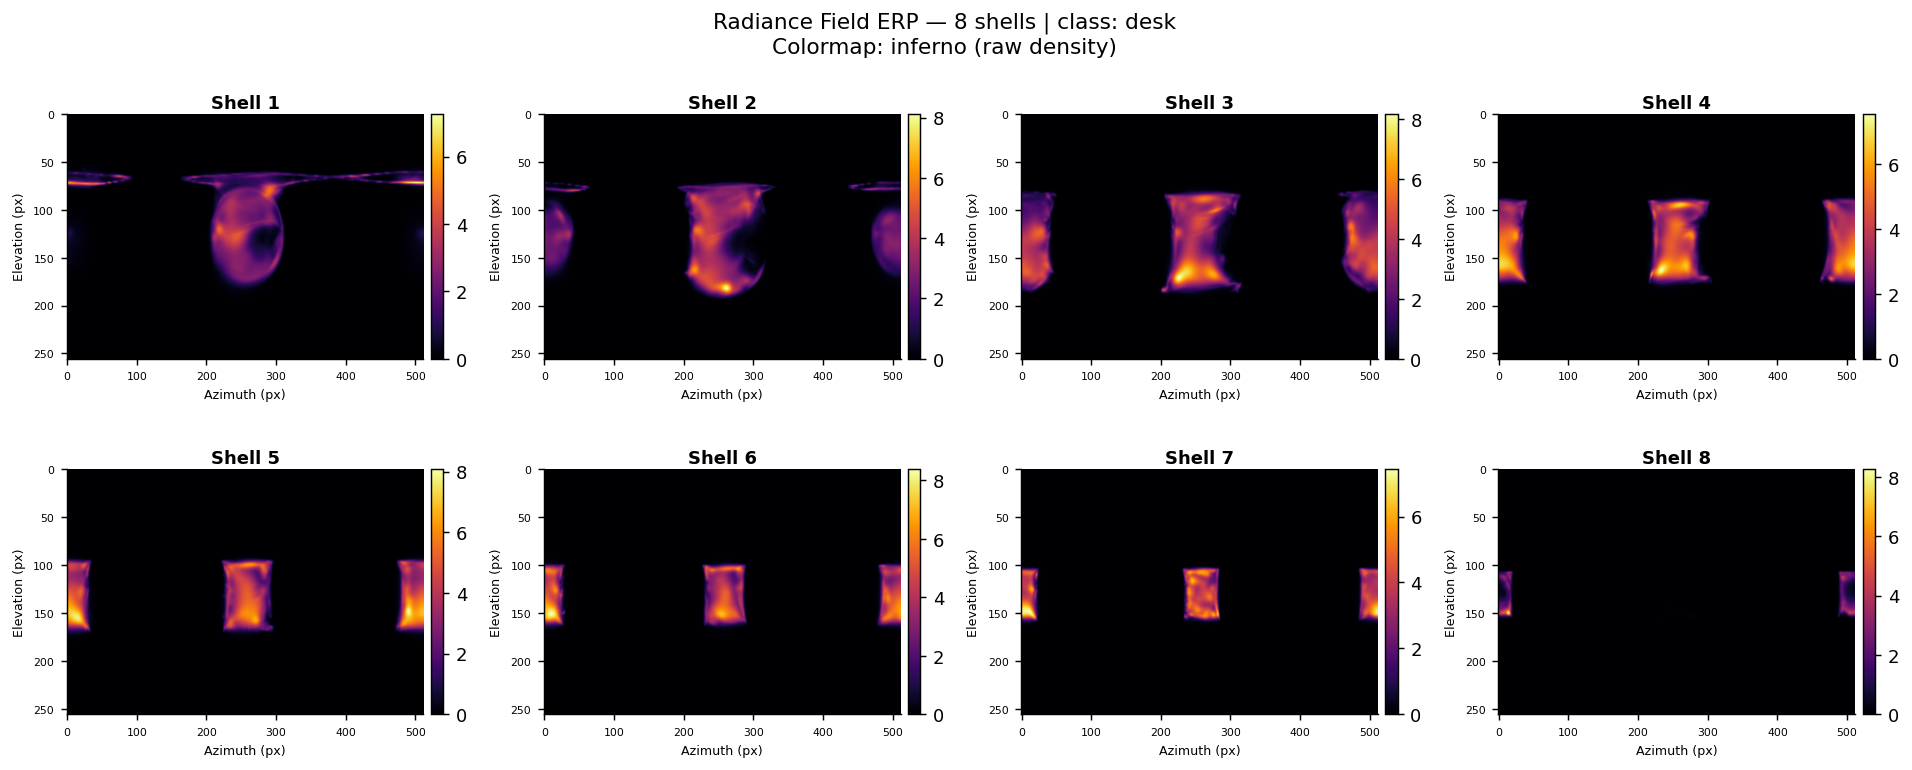

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.25})

for s, ax in enumerate(axes.flat):
    d = gaussian_filter(erp[s], sigma=0.8)
    im = ax.imshow(d, cmap='inferno', aspect='auto', interpolation='bilinear')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(f'Shell {s+1}', fontsize=10, pad=3)
    ax.set_xlabel('Azimuth (px)', fontsize=7)
    ax.set_ylabel('Elevation (px)', fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle(
    f'Radiance Field ERP — 8 shells | class: {FOCUS_CLASS}\n'
    f'Colormap: inferno (raw density)',
    fontsize=12, y=1.01,
)
fig.savefig(FIG_DIR / '1_shell_strip.pdf', bbox_inches='tight')
plt.show()

---
## Section 2 — RGB Composite

Map three shells to the R, G, B channels of a single colour image.  This gives an
immediate visual sense of how inner and outer shells partition the object.

- **Left** — inner/mid/outer mapping: S1→R, S4→G, S8→B
- **Right** — equal spacing: S1→R, S3→G, S5→B and S2→R, S6→G, S8→B

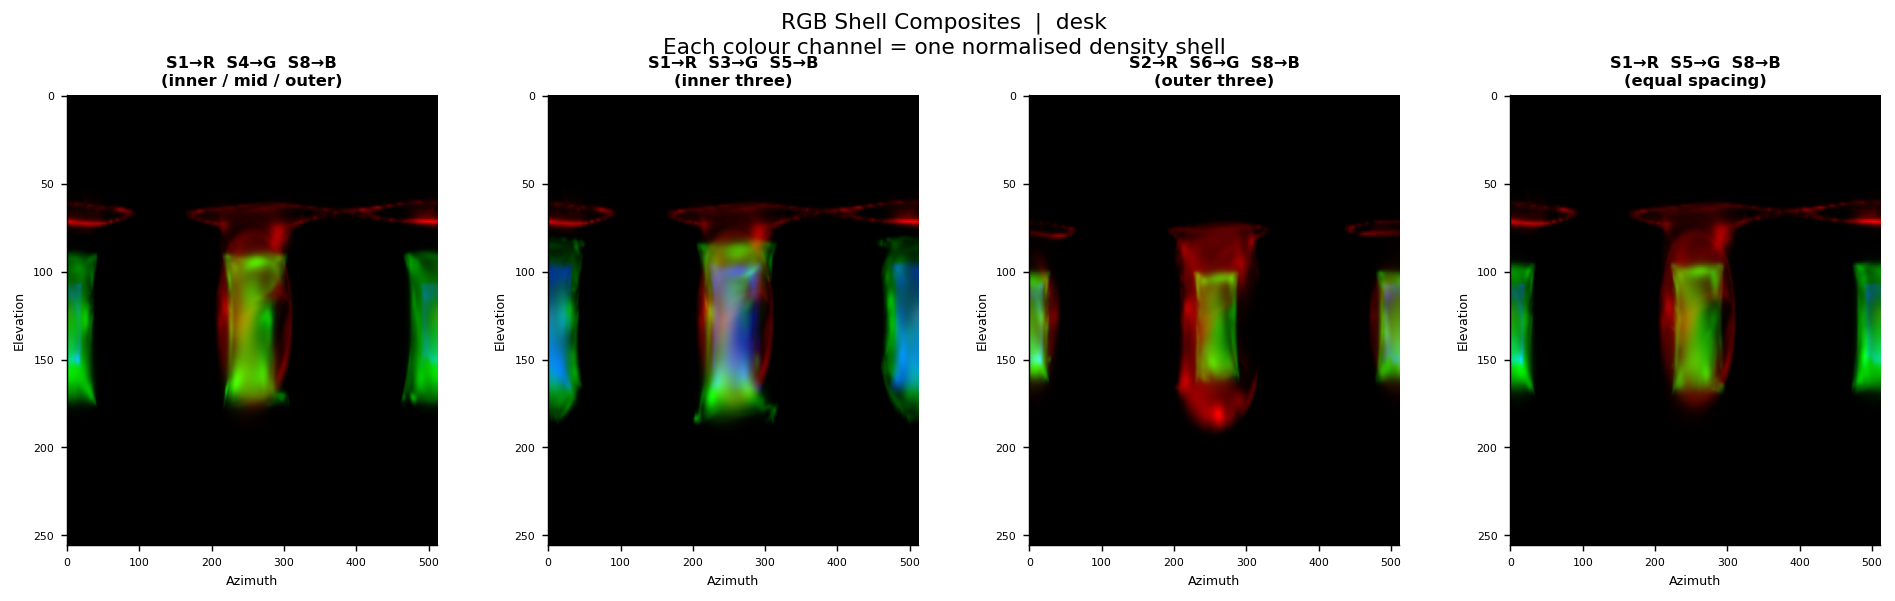

In [5]:
def make_rgb_composite(erp_arr, r_ch, g_ch, b_ch, smooth=0.8):
    """Build a normalised (H, W, 3) uint8 RGB composite from three ERP shells."""
    ch = [gaussian_filter(erp_arr[c], sigma=smooth) for c in (r_ch, g_ch, b_ch)]
    rgb = np.stack([normalise(c) for c in ch], axis=-1)
    return (rgb * 255).astype(np.uint8)

combos = [
    ((0, 3, 7), 'S1→R  S4→G  S8→B\n(inner / mid / outer)'),
    ((0, 2, 4), 'S1→R  S3→G  S5→B\n(inner three)'),
    ((1, 5, 7), 'S2→R  S6→G  S8→B\n(outer three)'),
    ((0, N_SHELLS//2, N_SHELLS-1), f'S1→R  S{N_SHELLS//2+1}→G  S{N_SHELLS}→B\n(equal spacing)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5),
                          gridspec_kw={'wspace': 0.3})

for ax, ((r, g, b), title) in zip(axes, combos):
    rgb_img = make_rgb_composite(erp, r, g, b)
    ax.imshow(rgb_img, aspect='auto')
    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlabel('Azimuth', fontsize=7)
    ax.set_ylabel('Elevation', fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle(
    f'RGB Shell Composites  |  {FOCUS_CLASS}\n'
    'Each colour channel = one normalised density shell',
    fontsize=12, y=1.02,
)
fig.savefig(FIG_DIR / '2_rgb_composite.pdf', bbox_inches='tight')
plt.show()

---
## Section 3 — Max-Intensity Projection (MIP) and Depth Map

**MIP** collapses the shell axis by taking the maximum density across all shells
at each pixel — analogous to X-ray projection in medical imaging.

**Depth map** shows the *first* shell index that exceeds a density threshold,
approximating a surface depth estimation.

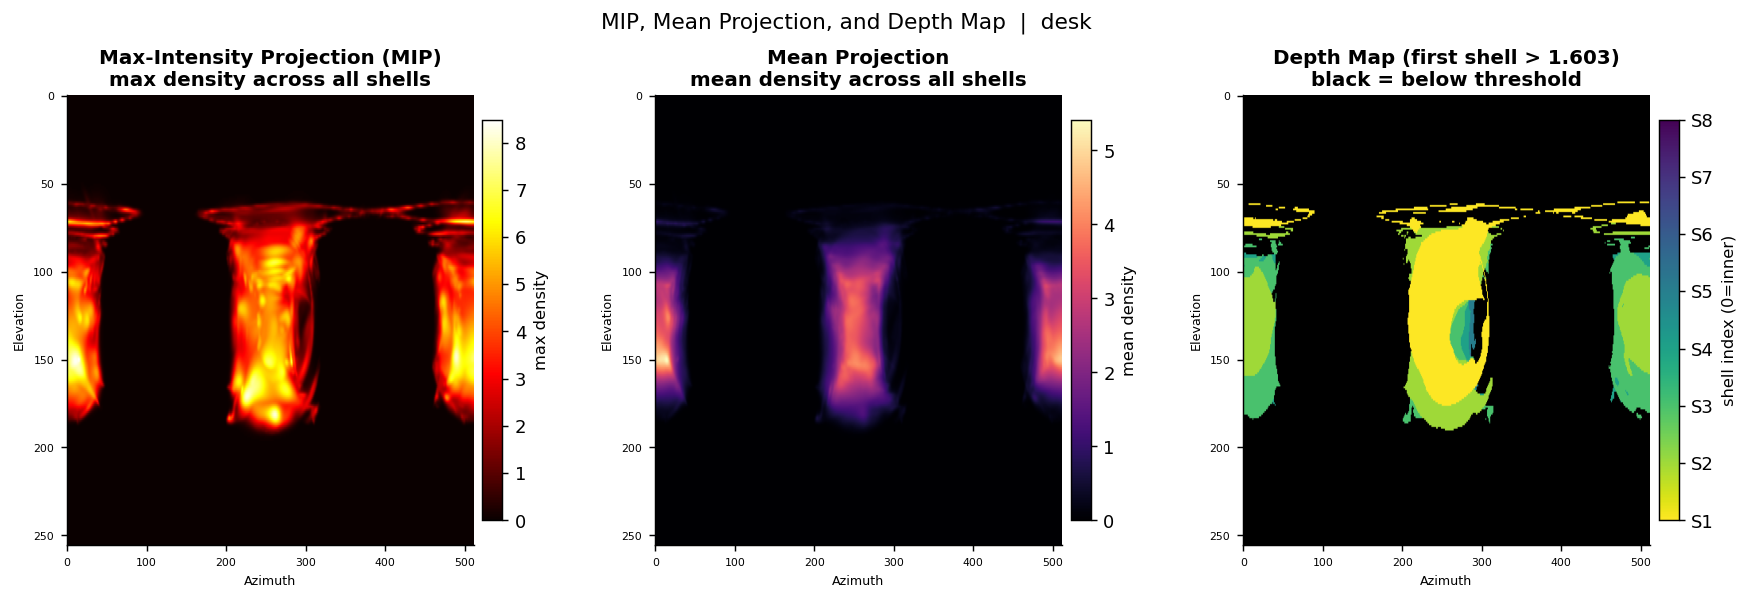

MIP    range  : [0.0000, 10.6838]
Depth  coverage: 15.5% of pixels above threshold


In [6]:
mip = erp.max(axis=0)                             # (H, W) — max over shells
mean_proj = erp.mean(axis=0)                      # (H, W) — mean over shells

# depth map: index of first shell that exceeds threshold
threshold = erp.max() * 0.15
above = erp > threshold                           # (N_shells, H, W) bool
depth_map = np.argmax(above, axis=0).astype(float)  # (H, W) — first shell hit
depth_map[~above.any(axis=0)] = np.nan            # pixels never exceeding threshold → NaN

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5),
                          gridspec_kw={'wspace': 0.35})

im0 = axes[0].imshow(gaussian_filter(mip, 0.8), cmap='hot', aspect='auto')
axes[0].set_title('Max-Intensity Projection (MIP)\nmax density across all shells', pad=5)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label='max density')

im1 = axes[1].imshow(gaussian_filter(mean_proj, 0.8), cmap='magma', aspect='auto')
axes[1].set_title('Mean Projection\nmean density across all shells', pad=5)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label='mean density')

cmap_depth = plt.cm.viridis_r.copy()
cmap_depth.set_bad('black', alpha=1.0)
im2 = axes[2].imshow(depth_map, cmap=cmap_depth, aspect='auto',
                     vmin=0, vmax=N_SHELLS - 1)
axes[2].set_title(f'Depth Map (first shell > {threshold:.3f})\nblack = below threshold', pad=5)
cbar2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
cbar2.set_label('shell index (0=inner)')
cbar2.set_ticks(range(N_SHELLS))
cbar2.set_ticklabels([f'S{i+1}' for i in range(N_SHELLS)])

for ax in axes:
    ax.set_xlabel('Azimuth', fontsize=7)
    ax.set_ylabel('Elevation', fontsize=7)
    ax.tick_params(labelsize=6)

fig.suptitle(f'MIP, Mean Projection, and Depth Map  |  {FOCUS_CLASS}', fontsize=12, y=1.02)
fig.savefig(FIG_DIR / '3_mip_depth.pdf', bbox_inches='tight')
plt.show()
print(f'MIP    range  : [{mip.min():.4f}, {mip.max():.4f}]')
print(f'Depth  coverage: {(~np.isnan(depth_map)).mean()*100:.1f}% of pixels above threshold')

---
## Section 4 — Radial Depth Profile

For a fixed azimuth column (longitude), plot **density vs shell index** as a
2-D heatmap — equivalent to a side-view cross-section of the radial density field.

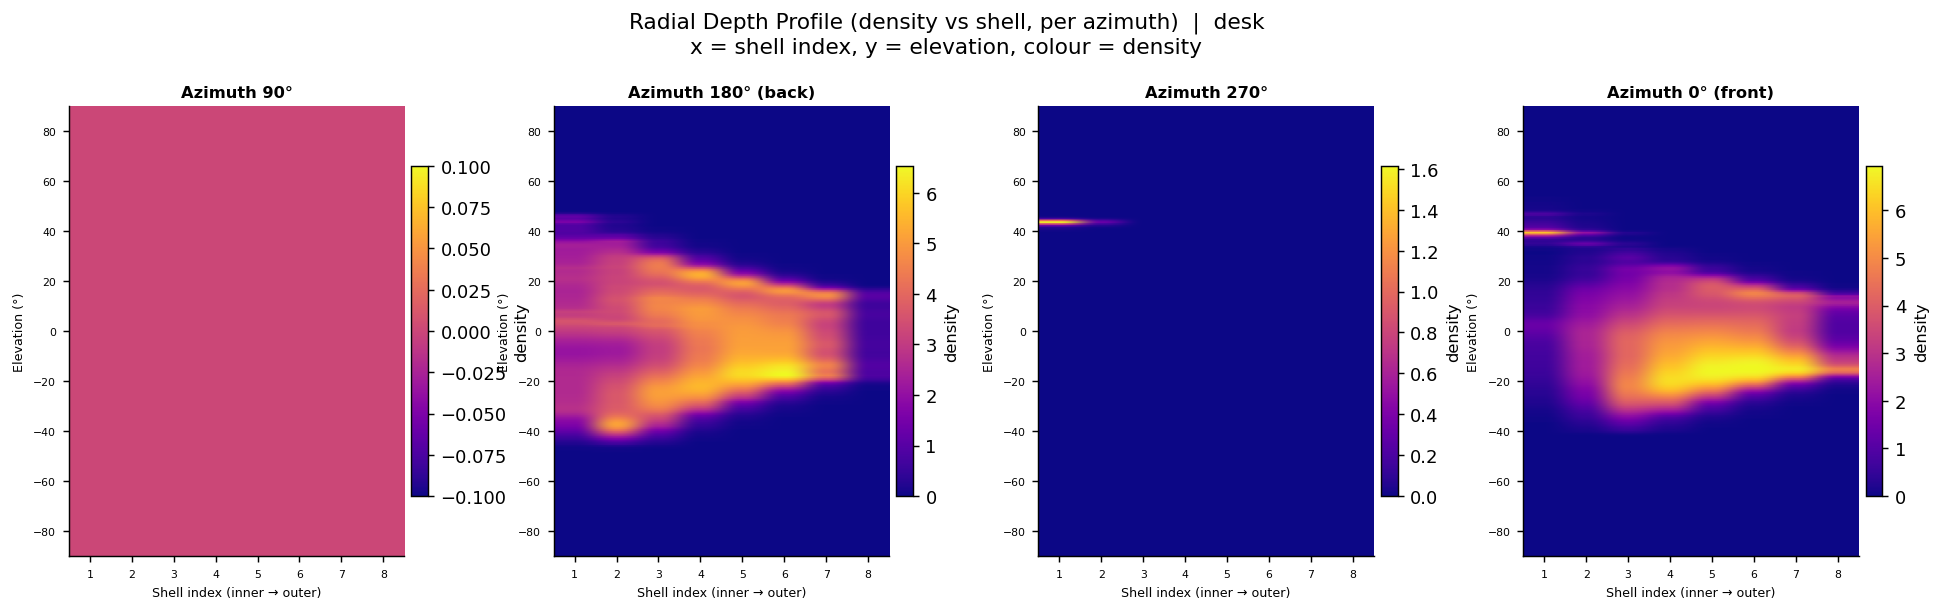

In [7]:
# Pick 4 representative azimuth columns (front, left, back, right)
azimuths = [W // 4, W // 2, 3 * W // 4, 0]
az_labels = ['90°', '180° (back)', '270°', '0° (front)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5),
                          gridspec_kw={'wspace': 0.35})

for ax, col, label in zip(axes, azimuths, az_labels):
    # profile[s, row] = density at shell s, elevation row, azimuth col
    profile = erp[:, :, col]    # (N_shells, H)
    profile_smooth = gaussian_filter(profile.astype(np.float64), sigma=0.6)

    lat_ticks = np.linspace(90, -90, H)
    im = ax.imshow(
        profile_smooth.T,      # (H, N_shells) — elevation on y-axis, shell on x
        cmap='plasma', aspect='auto',
        extent=[0.5, N_SHELLS + 0.5, -90, 90],
        origin='upper',
    )
    ax.set_title(f'Azimuth {label}', fontsize=9, pad=5)
    ax.set_xlabel('Shell index (inner → outer)', fontsize=7)
    ax.set_ylabel('Elevation (°)', fontsize=7)
    ax.set_xticks(range(1, N_SHELLS + 1))
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='density')

fig.suptitle(
    f'Radial Depth Profile (density vs shell, per azimuth)  |  {FOCUS_CLASS}\n'
    'x = shell index, y = elevation, colour = density',
    fontsize=12, y=1.04,
)
fig.savefig(FIG_DIR / '4_radial_depth_profile.pdf', bbox_inches='tight')
plt.show()

---
## Section 5 — Polar Plot: azimuth-averaged radial density

Average density over all elevations for each azimuth column, then plot on a polar
coordinate system where **radius = shell index** and **angle = azimuth**.  This
reveals whether the object is radially symmetric or has preferred orientations.

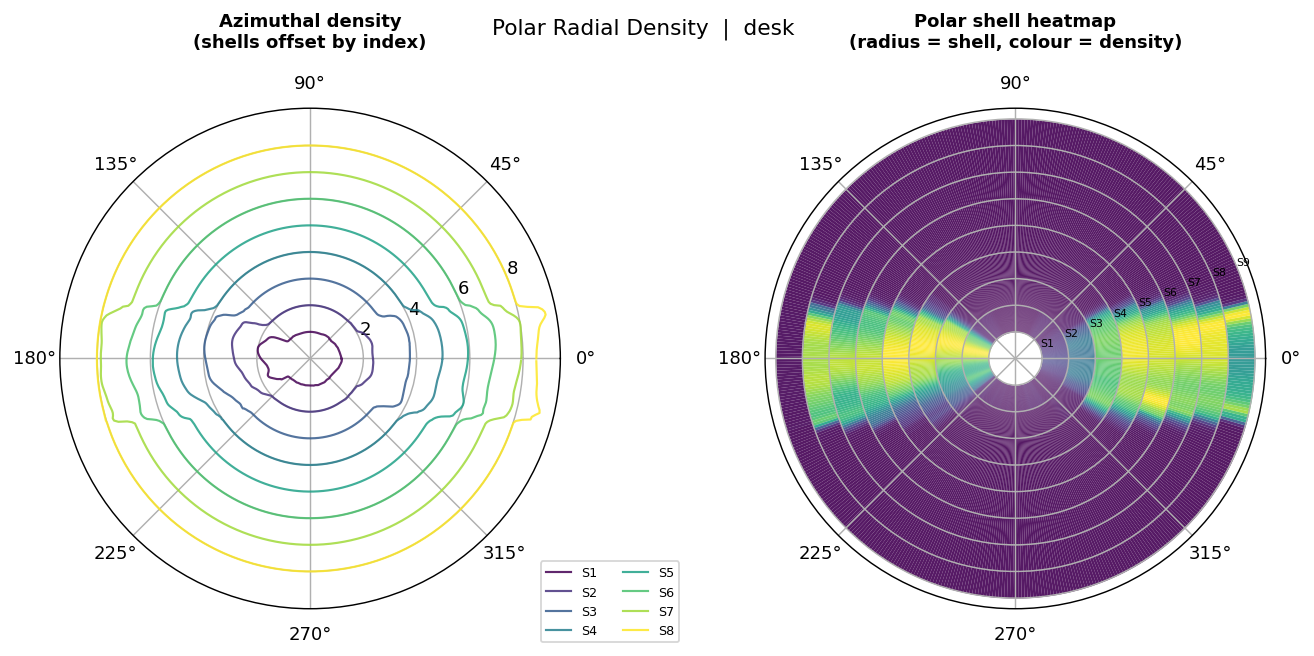

In [8]:
# Azimuth-averaged density: (N_shells, W)
az_mean = erp.mean(axis=1)    # (N_shells, W)

theta = np.linspace(0, 2 * np.pi, W, endpoint=False)  # (W,) azimuth angles

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          subplot_kw={'projection': 'polar'},
                          gridspec_kw={'wspace': 0.4})

cmap_shells = plt.cm.viridis
norm_shells = mcolors.Normalize(vmin=1, vmax=N_SHELLS)

for s in range(N_SHELLS):
    rho = normalise(az_mean[s]) + s + 1    # offset so shells don't overlap
    axes[0].plot(theta, rho,
                 color=cmap_shells(norm_shells(s + 1)),
                 linewidth=1.2, alpha=0.85,
                 label=f'S{s+1}')

axes[0].set_title('Azimuthal density\n(shells offset by index)', pad=15, fontsize=10)
axes[0].legend(loc='lower right', bbox_to_anchor=(1.25, -0.08),
               fontsize=7, ncol=2)

# Polar heatmap — use contourf in polar coords
r_edges = np.arange(1, N_SHELLS + 2)        # shell edges
for s in range(N_SHELLS):
    rho_inner = s + 1
    rho_outer = s + 2
    vals = normalise(az_mean[s])
    # Draw filled arc for each azimuth bin
    dtheta = 2 * np.pi / W
    for i in range(W):
        color = cmap_shells(vals[i])
        angles = [theta[i], theta[i] + dtheta]
        axes[1].fill_between(angles, rho_inner, rho_outer,
                             color=color, alpha=0.9, linewidth=0)

axes[1].set_yticks(range(1, N_SHELLS + 2))
axes[1].set_yticklabels([f'S{s}' for s in range(1, N_SHELLS + 2)], fontsize=6)
axes[1].set_title('Polar shell heatmap\n(radius = shell, colour = density)', pad=15, fontsize=10)

fig.suptitle(f'Polar Radial Density  |  {FOCUS_CLASS}', fontsize=12, y=1.02)
fig.savefig(FIG_DIR / '5_polar_density.pdf', bbox_inches='tight')
plt.show()

---
## Section 6 — Onion Cross-Section (meridian slice)

Slice the ERP at a fixed azimuth and show the density as concentric rings
on a 2-D cross-section plane.  Inner rings correspond to inner shells.

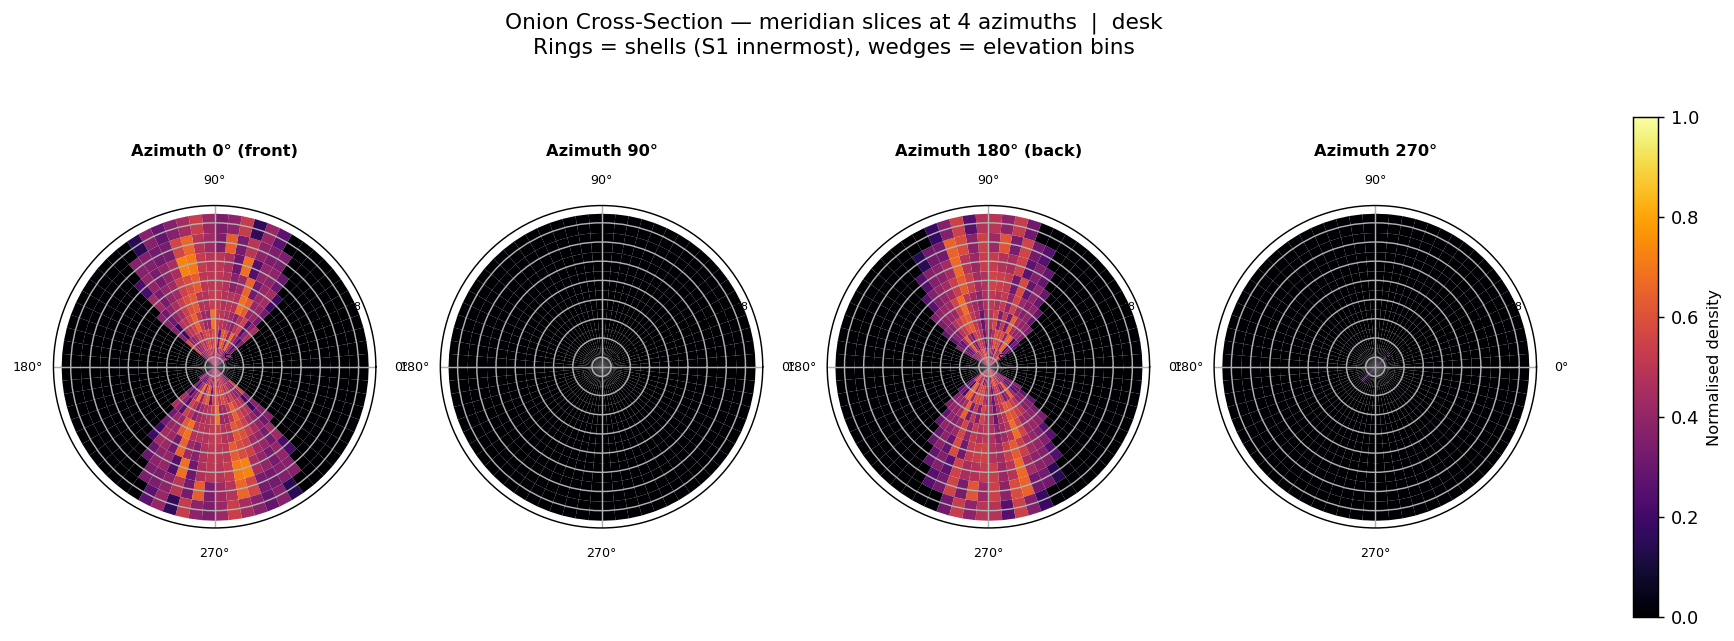

In [9]:
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

def onion_cross_section(erp_arr, az_col: int, n_elev_bins: int = 36, ax=None):
    """
    Polar plot where each ring = one shell, each angular segment = one
    elevation bin, colour = normalised density.
    """
    if ax is None:
        _, ax = plt.subplots(subplot_kw={'projection': 'polar'})

    # bin elevation rows into n_elev_bins wedges
    bins = np.array_split(np.arange(H), n_elev_bins)
    elev_angles = np.linspace(0, np.pi, n_elev_bins + 1)  # half-circle: 0..180°

    for s in range(N_SHELLS):
        r_inner = s / N_SHELLS
        r_outer = (s + 1) / N_SHELLS
        for e, (idx_group, a0, a1) in enumerate(
                zip(bins, elev_angles[:-1], elev_angles[1:])):
            val = normalise(erp_arr[s, idx_group, az_col]).mean()
            color = plt.cm.inferno(val)
            # fill both hemispheres (mirror)
            for theta_offset in (0, np.pi):
                ax.fill_between(
                    [a0 + theta_offset, a1 + theta_offset],
                    r_inner, r_outer,
                    color=color, linewidth=0,
                )

    ax.set_yticks([(s + 0.5) / N_SHELLS for s in range(N_SHELLS)])
    ax.set_yticklabels([f'S{s+1}' for s in range(N_SHELLS)], fontsize=6)
    ax.set_xticks(np.linspace(0, 2 * np.pi, 5)[:-1])
    ax.set_xticklabels(['0°', '90°', '180°', '270°'], fontsize=7)
    return ax


fig = plt.figure(figsize=(16, 5))
az_cols  = [0, W // 4, W // 2, 3 * W // 4]
az_names = ['0° (front)', '90°', '180° (back)', '270°']

for k, (col, name) in enumerate(zip(az_cols, az_names)):
    ax = fig.add_subplot(1, 4, k + 1, projection='polar')
    onion_cross_section(erp, az_col=col, ax=ax)
    ax.set_title(f'Azimuth {name}', fontsize=9, pad=10)

# shared colorbar
sm = plt.cm.ScalarMappable(cmap='inferno', norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.06)
cbar.set_label('Normalised density', fontsize=9)

fig.suptitle(
    f'Onion Cross-Section — meridian slices at 4 azimuths  |  {FOCUS_CLASS}\n'
    'Rings = shells (S1 innermost), wedges = elevation bins',
    fontsize=12, y=1.04,
)
fig.savefig(FIG_DIR / '6_onion_cross_section.pdf', bbox_inches='tight')
plt.show()

---
## Section 7 — Per-Shell Statistics: histograms and box plots

Distribution of raw density values at each shell.  Shells near the object surface
should show heavier tails (many near-zero pixels, a few high-density pixels).

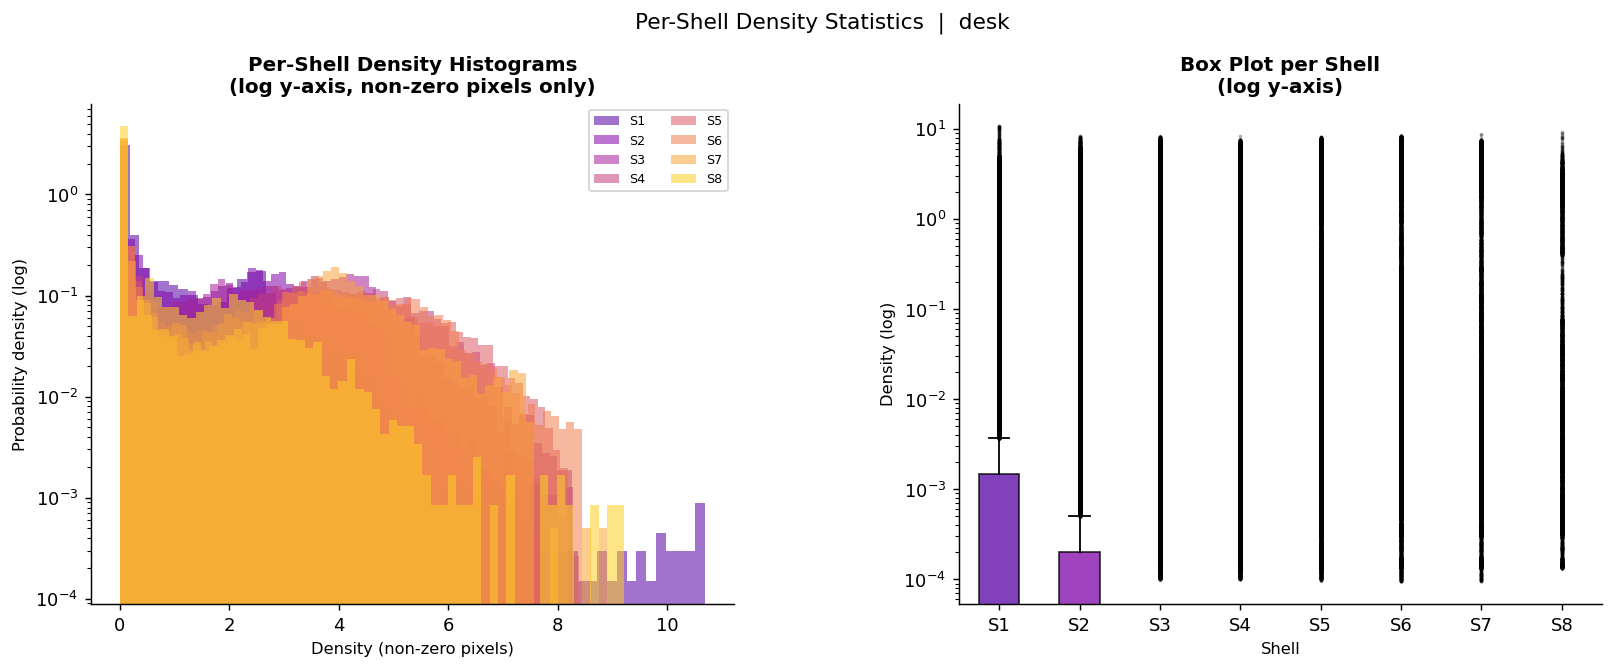

  Shell  |  mean      |  std       |  p50       |  p99
  ───────────────────────────────────────────────────────
  S1     |  0.228767  |  0.730372  |  0.000000  |  3.443604
  S2     |  0.349145  |  0.986080  |  0.000000  |  4.467321
  S3     |  0.446449  |  1.223164  |  0.000000  |  5.218046
  S4     |  0.383263  |  1.209380  |  0.000000  |  5.642558
  S5     |  0.308381  |  1.130895  |  0.000000  |  5.783485
  S6     |  0.233137  |  0.998420  |  0.000000  |  5.471134
  S7     |  0.161181  |  0.810425  |  0.000000  |  4.638885
  S8     |  0.031599  |  0.290172  |  0.000000  |  1.394210


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'wspace': 0.35})

colors = plt.cm.plasma(np.linspace(0.15, 0.9, N_SHELLS))

# --- histograms (overlaid, log scale) ----------------------------------------
ax = axes[0]
for s in range(N_SHELLS):
    vals = erp[s].ravel()
    vals_pos = vals[vals > 1e-6]
    if len(vals_pos) == 0:
        continue
    ax.hist(vals_pos, bins=60, color=colors[s], alpha=0.55,
            density=True, label=f'S{s+1}', histtype='stepfilled')

ax.set_yscale('log')
ax.set_xlabel('Density (non-zero pixels)')
ax.set_ylabel('Probability density (log)')
ax.set_title('Per-Shell Density Histograms\n(log y-axis, non-zero pixels only)')
ax.legend(fontsize=7, ncol=2)

# --- box plots per shell ------------------------------------------------------
ax = axes[1]
data_bp = [erp[s].ravel() for s in range(N_SHELLS)]
bp = ax.boxplot(
    data_bp, patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale('log')
ax.set_xticks(range(1, N_SHELLS + 1))
ax.set_xticklabels([f'S{s+1}' for s in range(N_SHELLS)])
ax.set_xlabel('Shell')
ax.set_ylabel('Density (log)')
ax.set_title('Box Plot per Shell\n(log y-axis)')

fig.suptitle(f'Per-Shell Density Statistics  |  {FOCUS_CLASS}', fontsize=12, y=1.02)
fig.savefig(FIG_DIR / '7_per_shell_stats.pdf', bbox_inches='tight')
plt.show()

print(f'  Shell  |  mean      |  std       |  p50       |  p99')
print(f'  {"─"*55}')
for s in range(N_SHELLS):
    v = erp[s].ravel()
    print(f'  S{s+1:1d}     |  {v.mean():.6f}  |  {v.std():.6f}  |  '
          f'{np.percentile(v,50):.6f}  |  {np.percentile(v,99):.6f}')

---
## Section 8 — Inter-Shell Correlation Matrix

Pearson correlation between flattened shell density maps.  High correlation between
adjacent shells is expected; low correlation between very inner and outer shells
indicates that each shell captures distinct geometric information.

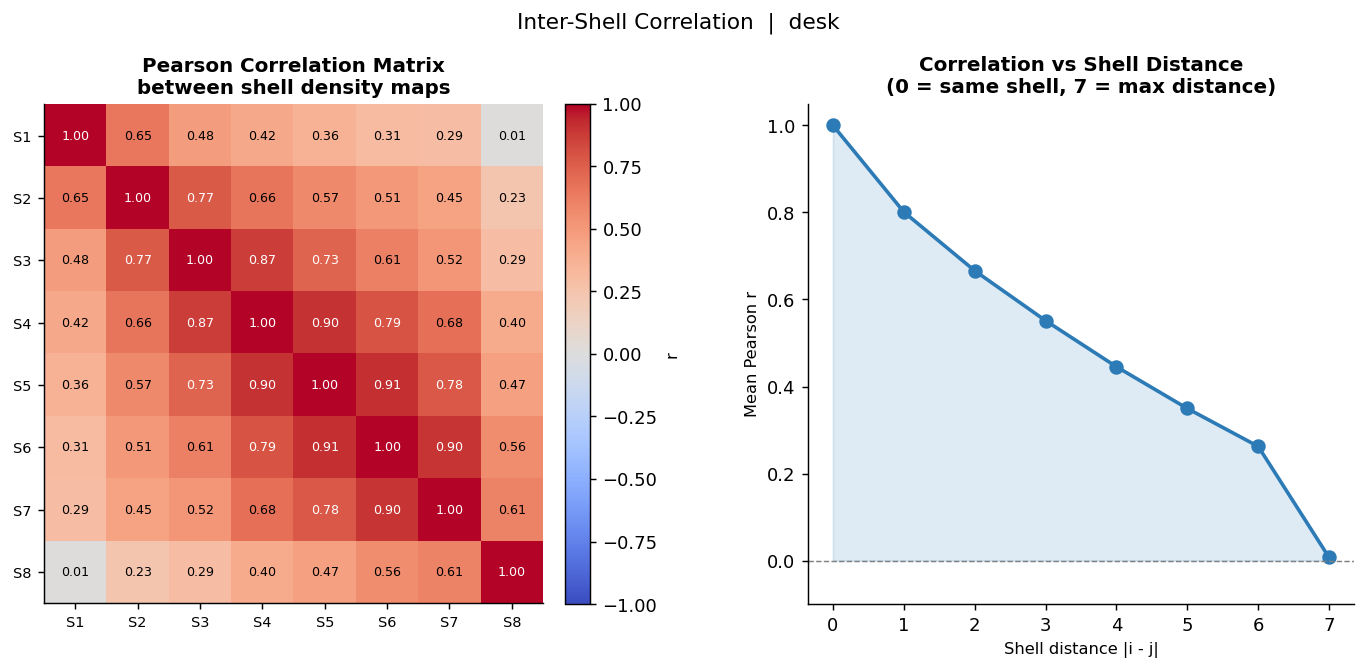

In [11]:
flat = erp.reshape(N_SHELLS, -1)    # (N_shells, H*W)

corr = np.zeros((N_SHELLS, N_SHELLS))
for i in range(N_SHELLS):
    for j in range(N_SHELLS):
        r, _ = pearsonr(flat[i], flat[j])
        corr[i, j] = r

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'wspace': 0.4})

# full correlation matrix
ax = axes[0]
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
for i in range(N_SHELLS):
    for j in range(N_SHELLS):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr[i,j]) < 0.7 else 'white')
ax.set_xticks(range(N_SHELLS))
ax.set_yticks(range(N_SHELLS))
ax.set_xticklabels([f'S{s+1}' for s in range(N_SHELLS)], fontsize=8)
ax.set_yticklabels([f'S{s+1}' for s in range(N_SHELLS)], fontsize=8)
ax.set_title('Pearson Correlation Matrix\nbetween shell density maps')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='r')

# correlation vs shell distance
ax = axes[1]
distances = np.arange(0, N_SHELLS)
mean_corr_by_dist = [
    np.mean([corr[i, j] for i in range(N_SHELLS)
             for j in range(N_SHELLS) if abs(i - j) == d])
    for d in distances
]
ax.plot(distances, mean_corr_by_dist, 'o-', color='#2c7bb6', linewidth=2, markersize=7)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.fill_between(distances, mean_corr_by_dist, alpha=0.15, color='#2c7bb6')
ax.set_xlabel('Shell distance |i - j|')
ax.set_ylabel('Mean Pearson r')
ax.set_title('Correlation vs Shell Distance\n(0 = same shell, 7 = max distance)')
ax.set_xticks(distances)
ax.set_ylim(-0.1, 1.05)

fig.suptitle(f'Inter-Shell Correlation  |  {FOCUS_CLASS}', fontsize=12, y=1.02)
fig.savefig(FIG_DIR / '8_shell_correlation.pdf', bbox_inches='tight')
plt.show()

---
## Section 9 — Class Gallery: RGB composite for all 10 ModelNet10 classes

One representative sample per class, shown as the S1→R / S4→G / S8→B composite.
Requires ERP cache for all 10 classes.

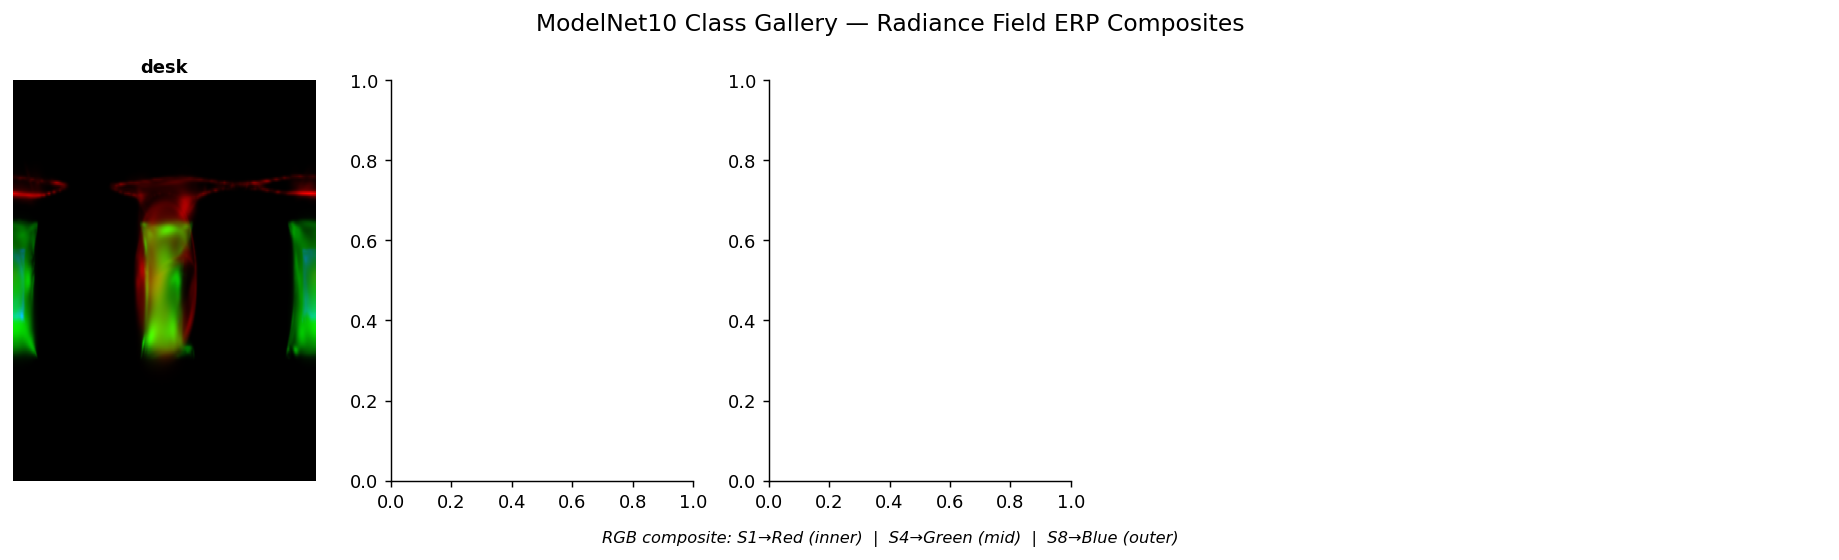

Rendered 1 / 10 classes.


In [12]:
available = [(cls, list_npys(cls, 'train')) for cls in MN10_CLASSES]
available = [(cls, paths) for cls, paths in available if paths]

if not available:
    print('No cached classes found — skipping gallery.')
else:
    n_cls = len(available)
    ncols = 5
    nrows = (n_cls + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows),
                              gridspec_kw={'hspace': 0.5, 'wspace': 0.25})
    axes_flat = axes.flat if nrows > 1 else [axes] if ncols == 1 else axes.flat

    for ax, (cls, paths) in zip(axes_flat, available):
        erp_cls = load_erp(paths[0])
        rgb_img = make_rgb_composite(erp_cls, 0, 3, 7)
        ax.imshow(rgb_img, aspect='auto')
        ax.set_title(cls, fontsize=10, pad=4)
        ax.axis('off')

    # blank out unused axes
    for ax in list(axes_flat)[n_cls:]:
        ax.axis('off')

    # legend
    fig.text(0.5, -0.01,
             'RGB composite: S1→Red (inner)  |  S4→Green (mid)  |  S8→Blue (outer)',
             ha='center', fontsize=9, style='italic')

    fig.suptitle('ModelNet10 Class Gallery — Radiance Field ERP Composites',
                 fontsize=13, y=1.01)
    fig.savefig(FIG_DIR / '9_class_gallery.pdf', bbox_inches='tight')
    plt.show()
    print(f'Rendered {n_cls} / 10 classes.')

---
## Section 10 — Same-Class Variation

Show several different instances of the same class side by side to visualise
intra-class variance in the radiance field representation.

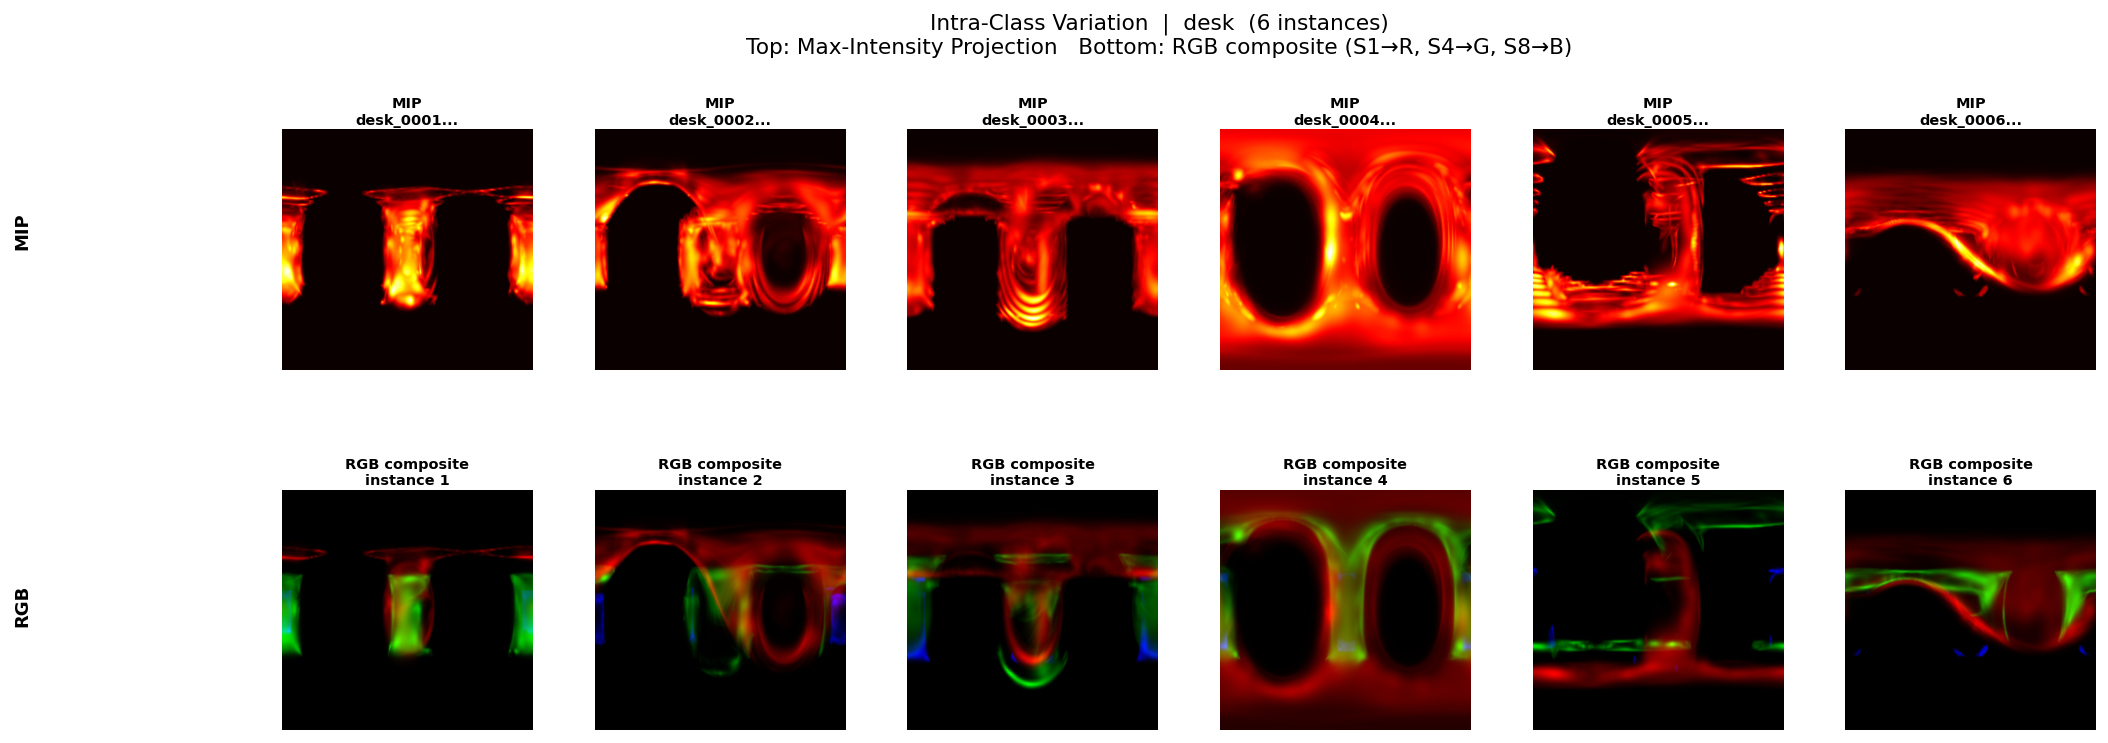

In [13]:
N_INSTANCES = 6
SHELL_SHOW  = 3    # which shell to display (0-indexed)

paths_focus = list_npys(FOCUS_CLASS, 'train')[:N_INSTANCES]
if not paths_focus:
    print(f'No cached samples for {FOCUS_CLASS}')
else:
    fig, axes = plt.subplots(2, N_INSTANCES, figsize=(18, 6),
                              gridspec_kw={'hspace': 0.5, 'wspace': 0.25})

    for k, p in enumerate(paths_focus):
        e = load_erp(p)
        # top row: MIP
        mip_k = e.max(axis=0)
        axes[0, k].imshow(gaussian_filter(mip_k, 0.8), cmap='hot', aspect='auto')
        axes[0, k].set_title(f'MIP\n{p.stem[:10]}...', fontsize=8, pad=3)
        axes[0, k].axis('off')

        # bottom row: RGB composite
        rgb_k = make_rgb_composite(e, 0, 3, 7)
        axes[1, k].imshow(rgb_k, aspect='auto')
        axes[1, k].set_title(f'RGB composite\ninstance {k+1}', fontsize=8, pad=3)
        axes[1, k].axis('off')

    fig.text(0.01, 0.75, 'MIP', va='center', rotation='vertical',
             fontsize=10, fontweight='bold')
    fig.text(0.01, 0.27, 'RGB', va='center', rotation='vertical',
             fontsize=10, fontweight='bold')

    fig.suptitle(
        f'Intra-Class Variation  |  {FOCUS_CLASS}  ({len(paths_focus)} instances)\n'
        f'Top: Max-Intensity Projection   Bottom: RGB composite (S1→R, S4→G, S8→B)',
        fontsize=12, y=1.03,
    )
    fig.savefig(FIG_DIR / '10_intraclass_variation.pdf', bbox_inches='tight')
    plt.show()

---
## All figures saved

In [14]:
pdfs = sorted(FIG_DIR.glob('*.pdf'))
print(f'{len(pdfs)} figures saved to {FIG_DIR}:')
for p in pdfs:
    print(f'  {p.name}')

10 figures saved to C:\DEV_ENV\source\UFRGS\TCC\gs-erp-3d-classification\experiments\figures\erp_viz:
  10_intraclass_variation.pdf
  1_shell_strip.pdf
  2_rgb_composite.pdf
  3_mip_depth.pdf
  4_radial_depth_profile.pdf
  5_polar_density.pdf
  6_onion_cross_section.pdf
  7_per_shell_stats.pdf
  8_shell_correlation.pdf
  9_class_gallery.pdf
